# 03d_train_double_qlearning – Train Double Q-Learning

**Chạy độc lập trên Kaggle.**

Flow:
1. Setup
2. Load data
3. Train Double Q-Learning (500 episodes trên train stream)
4. Save pkl → `experiments/saved_models/double_qlearning.pkl`
5. Learning curve

## 1. Setup

In [ ]:
#!git clone https://github.com/Briannguyen3106/RL-concept-drift.git
#%cd RL-concept-drift
#!pip install -r requirements.txt

Cloning into 'RL-concept-drift'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (128/128), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 128 (delta 45), reused 113 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (128/128), 11.44 MiB | 24.71 MiB/s, done.
Resolving deltas: 100% (45/45), done.
/kaggle/working/RL-concept-drift


In [2]:
import sys, os
import numpy as np
import pandas as pd

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from config import FULL_WINDOW_BATCHES, BATCH_SIZE
from utils.data_loader import AirlinesDataLoader
from models.LightGBM import LightGBM
from metrics.stream_metrics import StreamMetrics
from environment.drift_env import DriftStreamEnv
from utils.visualizer import plot_cumulative_reward

SAVE_DIR = os.path.join(PROJECT_ROOT, 'RL-concept-drift', 'experiments', 'saved_models')
print('Setup complete!')
from agents.td_agent import DoubleQLearningAgent

Setup complete!


## 2. Load Data

In [3]:
loader = AirlinesDataLoader()
X_train, y_train = loader.get_initial_train_data()

print(f'Train stream : {loader.n_train_batches} batches')
print(f'Test  stream : {loader.n_test_batches} batches')

[DataLoader] Loading data from: /kaggle/working/RL-concept-drift/data/Airlines.csv
[DataLoader] Raw shape: (539383, 9)
[DataLoader] 'Airline' → category dtype (18 unique values)
[DataLoader] 'AirportFrom' → category dtype (293 unique values)
[DataLoader] 'AirportTo' → category dtype (293 unique values)
[DataLoader] Initial train size : 20,000
[DataLoader] Stream size        : 519,383
[DataLoader] Class distribution (train) – 0: 11,529 | 1: 8,471
[DataLoader] Stream split → Train: 363 batches | Test: 156 batches
Train stream : 363 batches
Test  stream : 156 batches


## 3. Setup Environment

In [4]:
clf     = LightGBM()
metrics = StreamMetrics()
env     = DriftStreamEnv(loader, clf, metrics)
print('Environment ready.')

Environment ready.


## 4. Train Double Q-Learning

- Epsilon cố định = 0.1 (không decay) – môi trường non-stationary
- `mode='train'` → chỉ dùng train stream (70% đầu)
- Mỗi episode bắt đầu từ `TD_EPISODE_STARTS` khác nhau để tránh học vẹt

In [5]:
N_EPISODES = 2000

agent = DoubleQLearningAgent()
print(f'Agent    : {agent.name}')
print(f'Epsilon  : {agent.epsilon} (fixed)')
print(f'Gamma    : {agent.gamma}')
print(f'Alpha    : {agent.alpha}')
print(f'Episodes : {N_EPISODES}')

history = agent.train(env, n_episodes=N_EPISODES, verbose=True)

Agent    : DoubleQLearningAgent
Epsilon  : 0.1 (fixed)
Gamma    : 0.9
Alpha    : 0.1
Episodes : 2000

Training TD Agent: DoubleQLearningAgent for 2000 episodes
Fixed Epsilon: 0.1
[Classifier] Training on 20,000 samples...
[Classifier] Training complete.
Episode    1/2000 | Reward:   215.92 | Avg(10):   215.92 | Steps:  363
[Classifier] Training on 20,000 samples...
[Classifier] Training complete.
Episode    2/2000 | Reward:   175.83 | Avg(10):   195.87 | Steps:  291
[Classifier] Training on 20,000 samples...
[Classifier] Training complete.
Episode    3/2000 | Reward:   131.04 | Avg(10):   174.26 | Steps:  218
[Classifier] Training on 20,000 samples...
[Classifier] Training complete.
Episode    4/2000 | Reward:    90.02 | Avg(10):   153.20 | Steps:  145
[Classifier] Training on 20,000 samples...
[Classifier] Training complete.
Episode    5/2000 | Reward:    45.03 | Avg(10):   131.57 | Steps:   72
[Classifier] Training on 20,000 samples...
[Classifier] Training complete.
Episode    6/200

## 5. Save Agent

In [6]:
save_path = os.path.join(SAVE_DIR, 'double_qlearning.pkl')
agent.save(save_path)
print(f'Saved → {save_path}')
print(f'States visited : {len(agent.Q)}')

[DoubleQLearningAgent] Saved → /kaggle/working/RL-concept-drift/experiments/saved_models/double_qlearning.pkl
Saved → /kaggle/working/RL-concept-drift/experiments/saved_models/double_qlearning.pkl
States visited : 315


## 6. Learning Curve

Avg reward (all)    : 131.4327
Avg reward (last 10): 133.5001
Best episode reward : 231.6630
Action distribution : {'no_action': 203292, 'partial_update': 15362, 'full_retrain': 9033, 'alert': 107061, 'switch_model': 100852}
[Visualizer] Saved → /kaggle/working/RL-concept-drift/experiments/results/double_qlearning_learning_curve.png


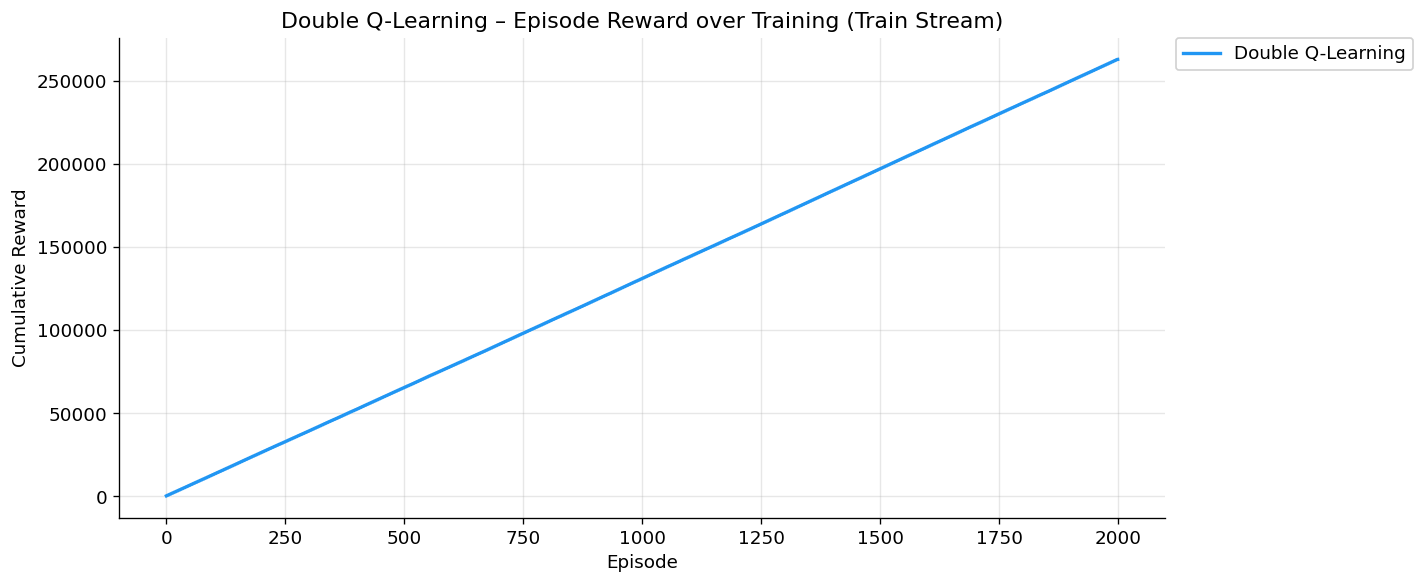

In [7]:
rewards = history['episode_rewards']
print(f'Avg reward (all)    : {np.mean(rewards):.4f}')
print(f'Avg reward (last 10): {np.mean(rewards[-10:]):.4f}')
print(f'Best episode reward : {max(rewards):.4f}')
print(f'Action distribution : {history["action_counts"]}')

plot_cumulative_reward(
    {'Double Q-Learning': rewards},
    title    = 'Double Q-Learning – Episode Reward over Training (Train Stream)',
    filename = 'double_qlearning_learning_curve.png',
)

## 7. Quick Sanity Check – Greedy Policy

In [8]:
# Set epsilon = 0.0 → pure greedy để kiểm tra policy đã học
agent.epsilon = 0.0
print(f'Top 10 states by Q-value spread:')
items = sorted(
    agent.Q.items(),
    key=lambda x: np.max(x[1]) - np.min(x[1]),
    reverse=True
)[:10]
for state, q in items:
    best_action = int(np.argmax(q))
    from environment.drift_env import ACTIONS
    print(f'  {state} → {ACTIONS[best_action]:<16} Q={np.round(q,3)}')

# Restore epsilon
agent.epsilon = 0.1

Top 10 states by Q-value spread:
  (0, 0, 0, 0, 0) → no_action        Q=[5.824 0.    0.    0.617 0.597]
  (2, 0, 1, 1, 0) → no_action        Q=[5.806 0.    0.    0.509 0.599]
  (1, 1, 3, 1, 1) → no_action        Q=[5.774 0.567 0.    0.881 0.   ]
  (0, 0, 3, 0, 0) → no_action        Q=[5.759 0.538 0.    0.    0.   ]
  (3, 1, 0, 2, 0) → no_action        Q=[5.543 0.936 1.537 0.    0.   ]
  (3, 0, 0, 2, 0) → no_action        Q=[5.536 0.    1.008 0.    0.599]
  (1, 2, 2, 2, 0) → no_action        Q=[5.532 0.    0.    0.    0.   ]
  (1, 1, 3, 2, 1) → no_action        Q=[5.969 0.522 0.547 1.545 0.96 ]
  (1, 0, 1, 2, 0) → no_action        Q=[5.822 1.096 0.679 1.144 0.42 ]
  (2, 2, 1, 1, 0) → no_action        Q=[5.397 0.    0.706 0.595 0.971]
